# Running PhyCV's own example code

This notebook installs and runs the **actual published `phycv` package**
(PyPI: [`phycv`](https://pypi.org/project/phycv/), source:
[JalaliLabUCLA/phycv](https://github.com/JalaliLabUCLA/phycv)) -- not this
repo's own from-scratch reimplementations of the same algorithms
([`dgs/pst.py`](../dgs/pst.py), [`dgs/phase_stretch_transform.py`](../dgs/phase_stretch_transform.py),
[`phycv_pst_sympy_torch_image_and_audio.ipynb`](phycv_pst_sympy_torch_image_and_audio.ipynb)).
Those exist to derive and verify the math from scratch; THIS notebook instead
runs the maintainers' own package, on their own demo images, with their own
documented parameters -- useful as a cross-check that this repo's
reimplementation agrees with the real thing, and as a normal example of
using a well-known third-party library.

PhyCV implements three physics-inspired computer-vision algorithms from the
Jalali lab, all built on the same "phase kernel in the Fourier domain" idea
this repo's own dispersion operator uses:

| Algorithm | What it does | Demo image (from PhyCV's own repo) |
|---|---|---|
| **PST** (Phase-Stretch Transform) | edge detection | `cell.png` |
| **PAGE** (Phase-stretch Adaptive Gradient-field Extractor) | directional/color-coded edge detection | `wind_rose.png` |
| **VEViD** (Vision Enhancement via Virtual diffraction) | low-light image enhancement | `street_scene.png` |

**What gets downloaded:** three official demo PNGs (~2.5 MB total) from
`raw.githubusercontent.com/JalaliLabUCLA/phycv`, saved to `../data/phycv_demo_images/`
(already covered by this repo's `.gitignore`).

In [1]:
import sys, subprocess, importlib.util
if importlib.util.find_spec("phycv") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "phycv"], check=True)

import pathlib
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
import cv2
from phycv import PST, PAGE, VEVID

print("phycv installed and importable")

phycv installed and importable


## Download PhyCV's own demo images

Fetched directly from the package's GitHub repo (`assets/input_images/`) --
the same files referenced by name in the project's README.

In [2]:
IMG_DIR = pathlib.Path.cwd().parent / "data" / "phycv_demo_images"
IMG_DIR.mkdir(parents=True, exist_ok=True)
BASE_URL = "https://raw.githubusercontent.com/JalaliLabUCLA/phycv/main/assets/input_images/"

DEMO_IMAGES = ["cell.png", "wind_rose.png", "street_scene.png"]
for fname in DEMO_IMAGES:
    path = IMG_DIR / fname
    if not path.exists():
        urllib.request.urlretrieve(BASE_URL + fname, path)
    print(f"{fname}: {path.stat().st_size:,} bytes  ({path})")

cell.png: 1,439,504 bytes  (D:\Summer2026\Dispersion-Assisted-GS-Phase-Recovery\data\phycv_demo_images\cell.png)
wind_rose.png: 436,137 bytes  (D:\Summer2026\Dispersion-Assisted-GS-Phase-Recovery\data\phycv_demo_images\wind_rose.png)
street_scene.png: 665,518 bytes  (D:\Summer2026\Dispersion-Assisted-GS-Phase-Recovery\data\phycv_demo_images\street_scene.png)


## 1. PST -- Phase-Stretch Transform (edge detection)

Applies a bounded (arctan) phase kernel in the Fourier domain, then reads
the OUTPUT PHASE as an edge map -- the same "multiply the spectrum by a
phase kernel, then look at the phase" move as this repo's own dispersion
operator, just 2D and with a saturating rather than quadratic kernel (see
`dgs/phase_stretch_transform.py` for why that saturation matters for
images). Parameters below are PhyCV's own README values for `cell.png`.

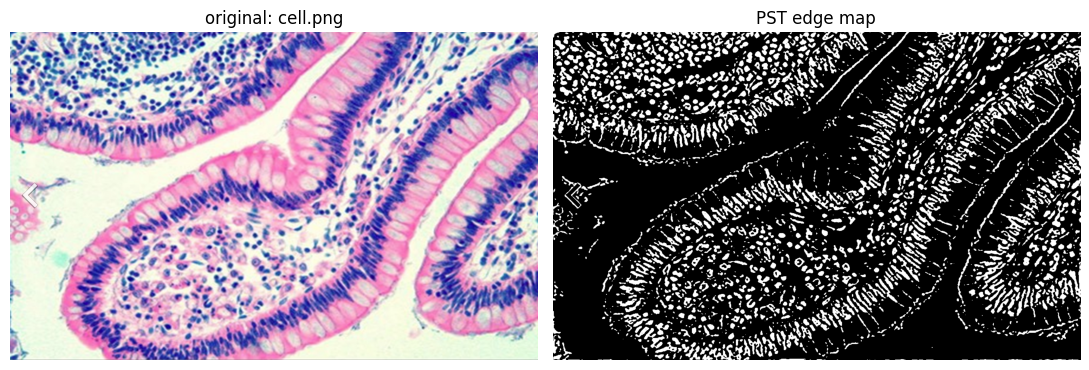

PST output: shape=(762, 1224), dtype=float32, range=[0.000, 1.000]


In [3]:
pst = PST()
pst_output = pst.run(
    img_file=str(IMG_DIR / "cell.png"),
    S=0.4, W=20,                              # phase strength, warp strength
    sigma_LPF=0.1,                            # low-pass denoising width
    thresh_min=0.0, thresh_max=0.8,           # feature thresholds
    morph_flag=1,                             # apply morphological cleanup
)

original = cv2.cvtColor(cv2.imread(str(IMG_DIR / "cell.png")), cv2.COLOR_BGR2RGB)
fig, axs = plt.subplots(1, 2, figsize=(11, 5))
axs[0].imshow(original); axs[0].set_title("original: cell.png"); axs[0].axis("off")
axs[1].imshow(pst_output, cmap="gray"); axs[1].set_title("PST edge map"); axs[1].axis("off")
plt.tight_layout(); plt.show()
print(f"PST output: shape={pst_output.shape}, dtype={pst_output.dtype}, range=[{pst_output.min():.3f}, {pst_output.max():.3f}]")

## 2. PAGE -- Phase-stretch Adaptive Gradient-field Extractor

PAGE extends PST with TWO passband filters (one normal, one log-normal in
frequency) tuned by `direction_bins` orientation channels, producing a
color-coded map of edge ORIENTATION, not just edge presence. Parameters
below are PhyCV's own README values for `wind_rose.png` (a natural choice
for a directional-edge demo).

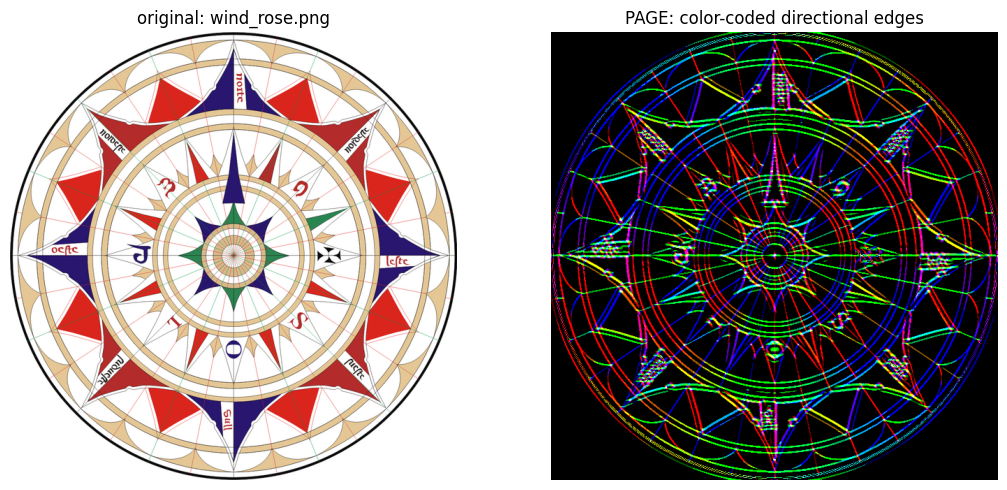

PAGE output: shape=(641, 640, 3), dtype=float64, range=[0.000, 1.000]


In [4]:
page = PAGE(direction_bins=10)
page_output = page.run(
    img_file=str(IMG_DIR / "wind_rose.png"),
    mu_1=0, mu_2=0.35, sigma_1=0.05, sigma_2=0.8,   # passband filter centers/widths
    S1=0.8, S2=0.8,                                  # phase strengths
    sigma_LPF=0.1, thresh_min=0.0, thresh_max=0.9, morph_flag=1,
)

original2 = cv2.cvtColor(cv2.imread(str(IMG_DIR / "wind_rose.png")), cv2.COLOR_BGR2RGB)
fig, axs = plt.subplots(1, 2, figsize=(11, 5))
axs[0].imshow(original2); axs[0].set_title("original: wind_rose.png"); axs[0].axis("off")
axs[1].imshow(page_output); axs[1].set_title("PAGE: color-coded directional edges"); axs[1].axis("off")
plt.tight_layout(); plt.show()
print(f"PAGE output: shape={page_output.shape}, dtype={page_output.dtype}, range=[{page_output.min():.3f}, {page_output.max():.3f}]")

## 3. VEViD -- Vision Enhancement via Virtual diffraction and coherent Detection

VEViD applies a phase kernel to the image's brightness (V) channel in HSV
space and reads the result back out as an enhanced brightness -- built for
low-light image enhancement without the noise amplification a naive
brightness stretch would cause. Parameters below are PhyCV's own README
values for `street_scene.png`.

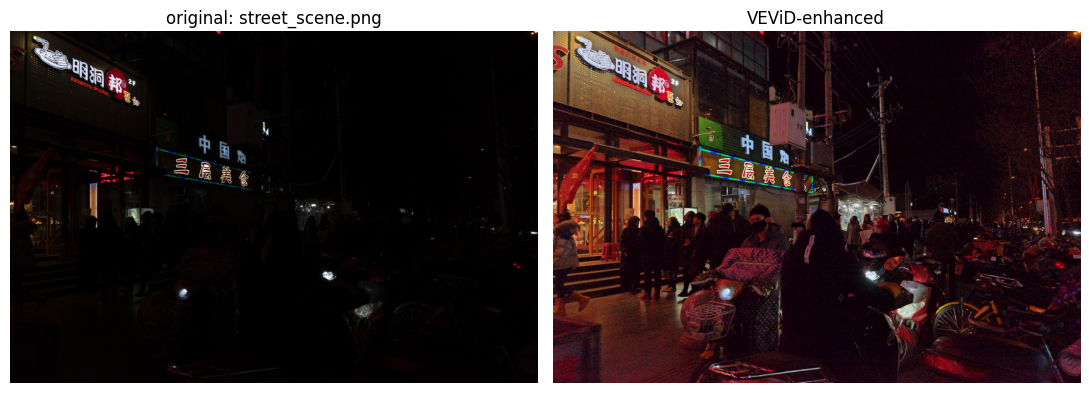

VEViD output: shape=(720, 1080, 3), dtype=uint8, range=[0, 255]


In [5]:
vevid = VEVID()
vevid_output = vevid.run(
    img_file=str(IMG_DIR / "street_scene.png"),
    S=0.2, T=0.001,     # phase strength, spectral phase variance
    b=0.16, G=1.4,       # regularization term, phase-activation gain
    color=False,          # enhance brightness (V channel), not saturation
)

original3 = cv2.cvtColor(cv2.imread(str(IMG_DIR / "street_scene.png")), cv2.COLOR_BGR2RGB)
fig, axs = plt.subplots(1, 2, figsize=(11, 5))
axs[0].imshow(original3); axs[0].set_title("original: street_scene.png"); axs[0].axis("off")
axs[1].imshow(vevid_output); axs[1].set_title("VEViD-enhanced"); axs[1].axis("off")
plt.tight_layout(); plt.show()
print(f"VEViD output: shape={vevid_output.shape}, dtype={vevid_output.dtype}, "
      f"range=[{vevid_output.min()}, {vevid_output.max()}]")

## Notes

- **GPU variants exist** (`PST_GPU`, `PAGE_GPU`, `VEVID_GPU`) built on `torch`;
  this environment installed CPU-only torch (`torch.cuda.is_available()` is
  `False` here), so this notebook stuck to the CPU classes. The GPU classes
  share the identical parameter names/values used above.
- **Cross-check, don't duplicate:** if you want to compare this package's PST
  output against this repo's own from-scratch derivation, run the same
  `cell.png` (or any image) through `dgs.phase_stretch_transform` and
  compare -- the underlying math (arctan-saturating phase kernel, FFT2 ->
  multiply -> IFFT2 -> angle) should agree qualitatively even though the
  exact kernel normalization differs slightly between the two implementations.